SHAP = Açıklanabilir AI. Gürültüyü azalmak için anomalileri tespit etmemiz lazım. Tespit etmek de yeterli değildir. Direkt modelin anomali belirlediği pencereye bakarak hangi sensörden dolayı anomali belirlediği, bunların birbiri ile ilişkileri ve modelin karar verirken ki ağırlıklarının incelenmesi gerekecek.

Örneğin:
Kayıt #45231 → Anomali skoru yüksek
 -- SHAP değerleri:
 -- Oil_temperature_diff_1h  : +2.3  → Anomaliye en çok katkı yapan
 -- Motor_current_rmean_6h   : +1.8  → İkinci en önemli
 -- TP2_lag_1h               : +0.9  → Üçüncü
 -- TP3_rmean_24h            : -0.3  → Anomali olmadığına işaret ediyor

 Model neden anomali dedi? Hangi sensör kararı tetikledi? Bunu görsel olarak analiz edeceğiz. İş birim metrikleri sensörleri inceleyeceğiz. Anomali skorlarını zaman serisinde görselleştireceğiz.

In [5]:
""" DOSYA YOLLARI """
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

kaggle da upload edilen dosyaların yol kontrolleri

In [ ]:
""" MODEL VE VERİLERİ YÜKLEME """
import polars as pl
import numpy as np
import pickle
import tensorflow as tf

# Yollar
FEATURES_PATH = "/kaggle/input/datasets/denizbyat/fatures-set/metropt3_features.parquet"        # özelliklerin bulunduğu Parquet dosyası
MODEL_PATH = "/kaggle/input/datasets/denizbyat/metropt3-features-data/lstm_autoencoder.keras"   # eğitilmiş LSTM model dosyası
SCALER_PATH = "/kaggle/input/datasets/denizbyat/metropt3-features-data/scaler.pkl"              # veri normalize edecek ölçekleyici dosyası
THRESHOLD_PATH = "/kaggle/input/datasets/denizbyat/metropt3-features-data/lstm_threshold.npy"   # eşik değeri dosyası

# Özellik dosyasını Yükle
df = pl.read_parquet(FEATURES_PATH)

# eğitimde kullanılan ölçekleyiciyi geri yüklüyoruz ki veriyi aynı şekilde ölçekleyebilelim yoksa model beklediği formatta veri alamaz ve sonuçlar anlamsız olur
with open(SCALER_PATH, "rb") as f:      # "rb" modunda açıyoruz çünkü pickle ikili formatta çalışır (bilgisayarın anlayacağı dilden 0-1)
    scaler = pickle.load(f)     # pickle.load() fonksiyonu ile dosyadan ölçekleyiciyi geri yüklüyoruz

autoencoder = tf.keras.models.load_model(MODEL_PATH)
threshold = np.load(THRESHOLD_PATH)

print(f"Veri: {df.shape[0]:,} satır, {df.shape[1]} sütun")
print(f"Eşik değeri: {threshold:.4f}")
print("Model yüklendi ✓")

Model, Veriler ve anomali tespiti için gerekli dosyalar yüklendi

In [ ]:
""" VERİ HAZIRLIĞI """
# Feature kolonları
feature_cols = [col for col in df.columns 
                if col not in ['timestamp', 'is_suspect']]  # timestamp ve is_suspect hariç tüm kolonlar özellik olarak kullanılacak

X = df.select(feature_cols).to_numpy()  # model girdileri
y = df['is_suspect'].to_numpy()     # hedef etiket (0: normal, 1: şüpheli)

# daha önce normalize ettiğimiz için sadece ölçekleyiciyi kullanarak bunu uyguluyoruz (bi yandan da veri sızıntıısı olmaması için iyi uygulamadır önceden eğitmiş olduğumuz scaler'ı kullanarak aynı şekilde ölçekleme yapıyoruz)
X_scaled = scaler.transform(X)

print(f"Feature matrix : {X_scaled.shape}")
print(f"Normal kayıt   : {(y == 0).sum():,}")
print(f"Şüpheli kayıt  : {(y == 1).sum():,}")

Sonuçlar böyledi şimdi bunların SHAP yani karar alımındaki ağırlık analizini yapıcaz Feature matrix : (1508308, 131) -- Normal kayıt   : 1,406,713 -- Şüpheli kayıt  : 101,595

In [ ]:
""" ÖRNEKLEM OLUŞTURMA """
import shap

# Zaman serisi penceleri oluşturma
timesteps =   # geçmişteki kaç zaman adımını kullanarak tahmin yapacağımızı belirler
def create_sequences(data, timesteps):
    sequences = []
    for i in range(len(data) - timesteps):      # veriyi belirlenen timesteps kadar kaydırarak pencereler oluşturuyoruz
        sequences.append(data[i:i+timesteps])
    return np.array(sequences)

# Anomali ve normal dengeli örneklem al (normal veri anomaliye gör çok olduğundan bu oranını dengelemek için aynı sayıda alınır)
anomali_idx = np.where(y == 1)[0][:500]  # ikisinden de ilk 500er veri alıyoruz
normal_idx = np.where(y == 0)[0][:500]      
sample_idx = np.concatenate([normal_idx, anomali_idx])  # seçilen verileri arka arkaya ekleyerek tek bir indeks dizisi oluşturuyoruz

X_sample = X_scaled[sample_idx]
y_sample = y[sample_idx]

# Sequence oluştur
X_sample_seq = create_sequences(X_sample, timesteps)    # oluşturduğumuz fonksiyon ile seçilen örnekleri zaman serisi pencerelerine dönüştürüyoruz. Bu değişken her yapılan 10arlı pencereleri tutacak ve modelin beklediği formatta olacak (örneğin (990, 10, 20) gibi)
y_sample_seq = y_sample[timesteps:]     # burasıda üstteki pencereler oluşturulurken kaydırılan kısmı göz önünde bulundurarak hedef etiketleri de aynı şekilde kaydırarak oluşturuyoruz. Burasıda tahminlerimizi tutacak
# yani x'in 0-9 arası ilk pencereye karşılık gelen y değeri 10. sıradaki etikete karşılık gelir çünkü ilk pencere 0-9 arası verileri içerir ve bu pencerenin hedefi 10. sıradaki veri olur
# bir sonraki xin 1-10 arası pencresi için ise y 11. sıradaki etikete karşılık tahmin yapar. Bu yüzden ynin ilk 0-9 arası tahmini olmayacak çünkü bu kısımda tam bir pencere oluşturulamadığı için modelin beklediği formatta veri olmaz ve sonuçlar anlamsız olur

print(f"SHAP örneklemi : {X_sample_seq.shape}")
print(f"Normal         : {(y_sample_seq == 0).sum()}")  # burası 490 olacak çünkü y için silinen ilk 10 etiket burasıydı
print(f"Anomali        : {(y_sample_seq == 1).sum()}")

shap hesaplamaları yoğun matematiksel işlemler olduğundan tüm veri setimiz de ciddi büyük olduğundan dolayı örneklem ile çalışıyoruz

Direkt çıktıları SHAP'e verdik ve AssertionError hatasını aldık. Bunun sebebi bizim ona verdiğimiz veriler 3 boyutlu (Örnek Sayısı, Zaman Adımları, Özellikler) olduğundandır. SHAP yapısı gereği sadece 1 boyutlu (regresyon gibi) yada 2 boyutlu (tablo filan) verilerle çalışabilir. Bizim set daha karmaşık olduğundan doğrulama hatası aldık. 

Bu hatayı çözmenin birkaç yolu var : 

1- Biz SHAP'e LSTM modelimizin çıktılarını direkt olarak veriyoruz yani model sonucu ne ise direkt 3 boyutlu olaraka veriyoruz. Direkt vermek yerine girdi ile çıktı arasındaki Ortalama Kare Hatasını (MSE) hesaplayan ve 1 boyutlu bir hata skorları dizisi döndüren bir sarmalayıcı (wrapper) model yazabiliriz. Böylece SHAP, hangi girdi özelliklerinin (features) hata skorunu artırdığını veya azalttığını analiz edebilir.

2- Modelimizin çıktısını düzleştirerek (flatten) 2 boyutlu (batch_size, timesteps * features) şekline dönüştüren ek bir katmanla sarmalayabiliriz. Bu bizde çok işe yaramaz çünkü flatten yaptığımızda ana resimden çok ufak zaman serileri ile inceleme yapmak zorunda kalır sadece anlık anomalileri tespit edebilirdik. Ayrıca Çıktıyı düzleştirdiğimizden tek boyutlu olacak ondan dolayı zaman algısıda kaybolacak Ortaya çıkacak SHAP grafikleri anlamsız, yorumlanamaz ve tamamen gürültülü (noisy) bir veri karmaşasına dönüşürdü. Bide bunların üstüne her birini düzleştirince inanılmaz parçalı kümeler oluşur shap saten çok ağır hesaplamalar yaptığından bunların her biri için ayrı hesaplama yapması inanılmaz ağır olurdu.

3- Belirli Bir Zaman Adımını (Timestep) hedefleyebilirdik ama yapmadık. Modelin sadece son zaman adımındaki tahminini veya özellikle ilgilendiğin tek bir özelliği döndüren bir sarmalayıcı da oluşturabilirdik. buda bize gelmez flattenın dezavantajlarından biri gibidir. biz ana resme odaklanıyoruz ayrıca buradan da çıkacak sonuç bölgesel oalcaktır.

In [ ]:
""" MAE HESAPLAMA VE SHAP DEĞERLERİ """
# LSTM çıktısını reconstruction error'a çeviren wrapper model
# SHAP'ın "hatayı" açıklayabilmesi için, çıktısı doğrudan hata (error) olan bir modele ihtiyacımız vardır. 
# Bu yüzden orijinal autoencoder modelinin çıktısını alıp, bunu gerçek girdi ile karşılaştırarak MSE (Mean Squared Error) hesaplayan yeni bir model oluşturuyoruz. Bu yeni modelin çıktısı her pencere için reconstruction error olacak ve biz bu hataları kullanarak anomalileri tespit edeceğiz. SHAP ise bu hataların hangi özelliklerden kaynaklandığını açıklayacak.
inputs = autoencoder.input      # giriş katmanı referansı
outputs = autoencoder.output    # çıkış katmanı referansı

# MSE hesaplayan lambda katmanı
mse_output = tf.keras.layers.Lambda(
    lambda x: tf.reduce_mean(tf.square(x[0] - x[1]), axis=[1, 2])   # girdi olarak orijinal veriyi ve modelin çıktısını alır, her pencere için MSE'yi hesaplar ve tek bir skora indirger (axis=[1, 2] ile her pencere için tüm özellikler üzerinden ortalama alınır)
)([inputs, outputs])

error_model = tf.keras.Model(inputs=inputs, outputs=mse_output)     # girdi olarak orijinal veriyi, çıktı olarak ise reconstruction error'ı veren yeni bir model oluşturuyoruz. Bu modelin çıktısı her pencere için reconstruction error olacak ve biz bu hataları kullanarak anomalileri tespit edeceğiz

# Sadece normal verilerden (y == 0) oluşan 50 örneklik bir küme seçilir.
# SHAP'a şunu demiş oluyorsunuz: "Bak, normalde hata bu seviyelerde olmalı. Eğer bir sapma varsa, bunun sorumlusu hangi özellik?"
background = X_sample_seq[y_sample_seq == 0][:50]   # SHAP için normal verilerden küçük bir arka plan veri seti oluşturuyoruz. Bu veri seti SHAP'ın beklenen değerini hesaplamak için kullanılacak ve bu yüzden sadece normal verilerden seçiyoruz çünkü anomaliler beklenen değeri bozabilir ve SHAP değerlerinin yorumlanmasını zorlaştırabilir. 

# SHAP - error_model'in türevlerini (gradyanlarını) kullanarak girdilerin hata üzerindeki etkisini hesaplar.
explainer = shap.GradientExplainer(error_model, background)

print("SHAP değerleri hesaplanıyor...")
shap_values = explainer.shap_values(X_sample_seq[:100])  # İlk 100 test örneği için SHAP değerlerini hesaplar

print(f"SHAP shape: {np.array(shap_values).shape}")
print("Tamamlandı ✓")

ÇIKTI : SHAP shape: (100, 10, 131, 131). ilginçtir ki 4 boyutlu bir veri çıktı. Biz SHAPe 3 boyutlu (100 örnek, 10 saniyelik/zamanlık adımlar, 131 farklı özellik) çıktı veri setini verdik. Her adımın tahmini ile gerçeği karşılaştırıp tüm setin tek bir MAE değerini hesaplayıp ve SHAP den bu hata da hangi adımın ne kadar payı olduğunu bulmasını istedik. Mantıken yine aynı şekilde aynı boyutlu matris çıktısı beklerken (3 boyutlu ama matris büyüklüğümüz adım x özellikden = 10x131 oluyor) 4 boyutlu bir çıktı üretti. Bunun sebebini gemini ve claudumuz "Keras ve SHAP entegrasyonunda yaşanan kronik bir bug yüzünden" olduğunu söylüyor. Yani biz tek bir MAE değeri üretip adımların bu değere katkılarına bakacakken (yine 131 değer çıkacaktı sonuç olarak); SHAP sanki her adım için üretmişiz ve adımların özelliklerinin birbirinin MAE değerleri arasındaki ilişkileride incele gibi anladı ve tamamen gereksiz özellikler kadar biribirleri içinde çapraz ilişkili bir boyut daha üretti. İstenileni yaptı (sonuçta bize lazım olan 1.admının 131 özelliğinin hataya toplam etkisi. evet belki bunların diğer adımların hatasına etkisinin araştırılmasının istemiyorduk ancak o devasa hesaplamayıda yaptı) orası ayrı ama sadece paketlemede sıkıntı çıkardı.

Bizim yapacağımız şey numpy ile ya bu 4 boyutlu seti ezerek (zaman serisini (bunu zaten ezecektik grafik için) ve fazladan olan boyutu) 2 boyutlu sete dönüştürüp grafikleştirmek burada toplamış oluyoruz tek tek hesapladığı değerleri fazladan boyutu ezerek yada saten bizim istediğimiz kısmı da hesaplamış orayı çekip almak.

Tek tek almak daha mantıklıymış gemini dediğine göre SHAP değeleri pozitif ve negatif değerler olduğundan birbirini sönümlüyormuş bunun yerine saten hesaplamış olduğu "1. girdinin 1. çıktıya etkisi", "2. girdinin 2. çıktıya etkisi" (Yani matrisin [..., i, i] kısımları) alıcaz. Diğer tüm çapraz ilişkiler çöpe atıcaz yani diagonalı alıcaz set 3 boyuta inecek. sonrada zaman serisinide ezip yani istediğimiz olan her adım için değerlerin 10 zaman adımı boyunca o sensörün yarattığı toplam anomali etkisinin ortalamalarını grafikleştiricez. Burada da sönümleme olmaması için az değer olduğundan diğer matrise nazaran mutlak değerli işlem  yapacağız. (bu zaman ezmeyi zaten yapıcaktık hatayla ilgisi yok 2 boyuta indirip grafikleştirmek içindir) - Kısaca 131 sensörün birbirinin hatasına etkisini de hesaplamış biz bunu istemiyoruz biz her sensörün kendi hataya etkisini istiyoruz yani her sensör için bir değer istiyoruz o da kendisinin etkisi.

In [ ]:
""" SHAP HATASI DÜZENLEME VE GÖRSELLEŞTİRME """
# 1- Çapraz ilişkilerden sadece köşegeni (diagonali) alıyoruz
# Mevcut şekil: (100, 10, 131, 131) -> Hedeflenen şekil: (100, 10, 131)
# np.diagonal, son iki boyutun (131, 131) sadece [i, i] olan eşleşmelerini çekecek yani bizim istediğimiz her pencerede sensörün hataya kendi etkisi.
shap_values_3d = np.diagonal(np.array(shap_values), axis1=2, axis2=3)   # axisler ile son iki özelliği belirttik

# 2- Zaman adımını ezme. Bunu zaten yapacatık görselleştirme için hata ile alakası yok.
# Etkilerin birbirini sıfırlamasını önlemek için mutlak değer (abs) alıyoruz. Çünkü SHAP değerleri poz ve neg birbirini sönümlemesin.
# Sonuç şekli - (100, 131)
shap_values_2d = np.mean(np.abs(shap_values_3d), axis=1)  # axis 1 ile zaman eksenini seçip ortalama alarak tek bir vektör haline getiriyoruz. 
# Bu şekilde her örnek için 131 özellik için tek bir SHAP değeri elde ediyoruz. Bu değerler, o özelliğin o örnekteki anomaliye katkısının ortalama etkisini temsil eder.  

print(f"Düzeltilmiş SHAP shape: {shap_values_2d.shape}")    # hata olmadan 100 örnek ve 131 özellik için SHAP değerlerini içeren bir matris elde ettik yani bu zaman olmayan sadece örnek ve veriler var bunu grafikte x ekseninde kullanıcaz

# 3- Orijinal veriyi de 2 boyuta uyarlamak
# Grafiği çizebilmek için SHAP'e, bu 100 örneğin gerçek feature değerlerini de vermeliyiz.
# SHAP değerlerinin zaman ortalamasını aldığımız için, orijinal verinin de zaman ortalamasını almak en mantıklısıdır.
X_sample_2d = np.mean(X_sample_seq[:100], axis=1)

# 4. AŞAMA: Nihai Summary Plot (Özet Grafiği)
# Bu grafik, hangi özelliğin (sensörün/değişkenin) anomaliyi en çok tetiklediğini gösterecek.
print("Grafik oluşturuluyor...")
shap.summary_plot(shap_values_2d, features=X_sample_2d)

1.adımda belirttiğimiz eksenlerin matrisinin köşegen değerlerini aldık. Bunlar bizim istediğimiz her sensörün hataya kendi etkisidir. Bu değerler yaptığı etkiye göre +, - olabilir. Bu adım sonrasında elimizde 3 Boyutlu istediğimiz matris geçer. 

2.adımda elimizde olan her sensörün 10 saniye içinde ve her saniye için etki değerini mutlak ortalamasını alıyoruz. Bu etki değerleri dediğim gibi birbirini sönümlememesi için mutlak. axis 1 ilede bu zaman eksenini seçip dediğimiz işlemleri yaparak ezdik. Her sensör için 10 değerin ortalmasını aldık. Elimize shap_values matrisi geçecek (100, 131). Bu matris SHAP grafiğinde x ekseni olacak.

3.adımda orjinal 3 boyutlu verimizin (Bu orjinal veri dediğimiz modele verdiğimiz sensörlerin o anki fiziksel yani gerçek gösteridiği değerlerin olduğu matris. sıcaklık 85, basınç 1.2 bar gibi değerler) yine 10 saniyelik orlamalarını alarak boyutu ezip 2d hale getiriyoruz. Burada da elimize x_sample_2d matrisi (100, 131) geçer. Bu matrisde renkleri belirleyecek. Şimdi diğer matris noktanın konumu belirliyo sapmaya göre bu da gerçek değerin yükseliğini renk tonuyla belirleyecek (yüksek kırmızı, düşük mavi).

Bu grafiğin faydası aynı anda 2 etkenide anlık izleyebilmemizdir. "Sıcaklık sensörü yüksek değerdeyken hatayı artırdı" veya "Basınç sensörü düşük değerdeyken hatayı artırdı" diyebilmemiz gerekir."Sıcaklık sensörü yüksek değerdeyken hatayı artırdı" veya "Basınç sensörü düşük değerdeyken hatayı artırdı" diyebilmemiz gerekir. Tek sıkıntı gerçek değerlerinde ortalamasını aldık. Ani sıçramaları törpülemiş olduk.

ÇIKTI

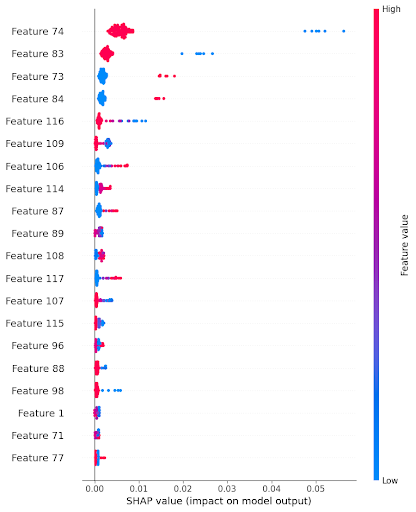

Öncelikle grafiğin sola yapışıp toplu olmasının sebebi mutlak alarak ortalama aldığımızdan sönümlemeyi engelledik. Ayrıca Renk skalası tehlikeyi değil sensörün o anki değerlerini ifade ediyorken x ekseni de hataya katkısını gösteriyor. Sıralamda en çok etkiyi yapan sıralaması.

feature 74 ve 83 - Bu iki sensörün değeri yüksekken (kırmızı) sistemde hiçbir sorun yok. Ancak bu değerler düştüğünde (mavi), sistem felç oluyor ve devasa bir anomali üretiyo ama bunun gerçek bir fiziksel basınç/sıcaklık düşüşü mü yoksa sensörün kablosunun kopup sisteme 0 (sıfır) veya NaN değeri göndermesi mi olduğunu bilemez. Veri kalitesindeki bir bozukluğu, fiziksel bir arızaymış gibi yorumluyor olabiliriz.

73 - 83 sensörlerinde ise durum tam tersi. Bu durumlara yol açan şeyin var olan verilerinden kaynaklandığını tespit etmemiz için sensörlerin verilerini inceleyeceğiz sonrasında daha sağlıklı çıkarımlar yapabiliriz. İlk amacımız herhangi bir NaN durumdan kaynaklanıyor olmaması.

In [ ]:
""" 74-83 SENSÖR İNCELEMESİ """
import matplotlib.pyplot as plt

# Feature 74 ve 83'ün indeksleri (Python 0'dan başladığı için indeksler 74 ve 83'tür)
features_to_check = [74, 83]

plt.figure(figsize=(15, 6))

# İlk 5 örneğin (örneğin 5 farklı makine veya zaman diliminin) 10 saniyelik hareketini çizdirelim
for i, f_idx in enumerate(features_to_check):
    plt.subplot(1, 2, i+1)
    
    # İlk 5 örneği (0'dan 5'e kadar) alıp 10 zaman adımı boyunca çizdiriyoruz
    for sample_idx in range(5):
        plt.plot(X_sample_seq[sample_idx, :, f_idx], marker='o', label=f'Örnek {sample_idx+1}')
        
    plt.title(f'Feature {f_idx} - Zaman Serisi Hareketi')
    plt.xlabel('Zaman Adımları (Timesteps)')
    plt.ylabel('Sensör Değeri')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

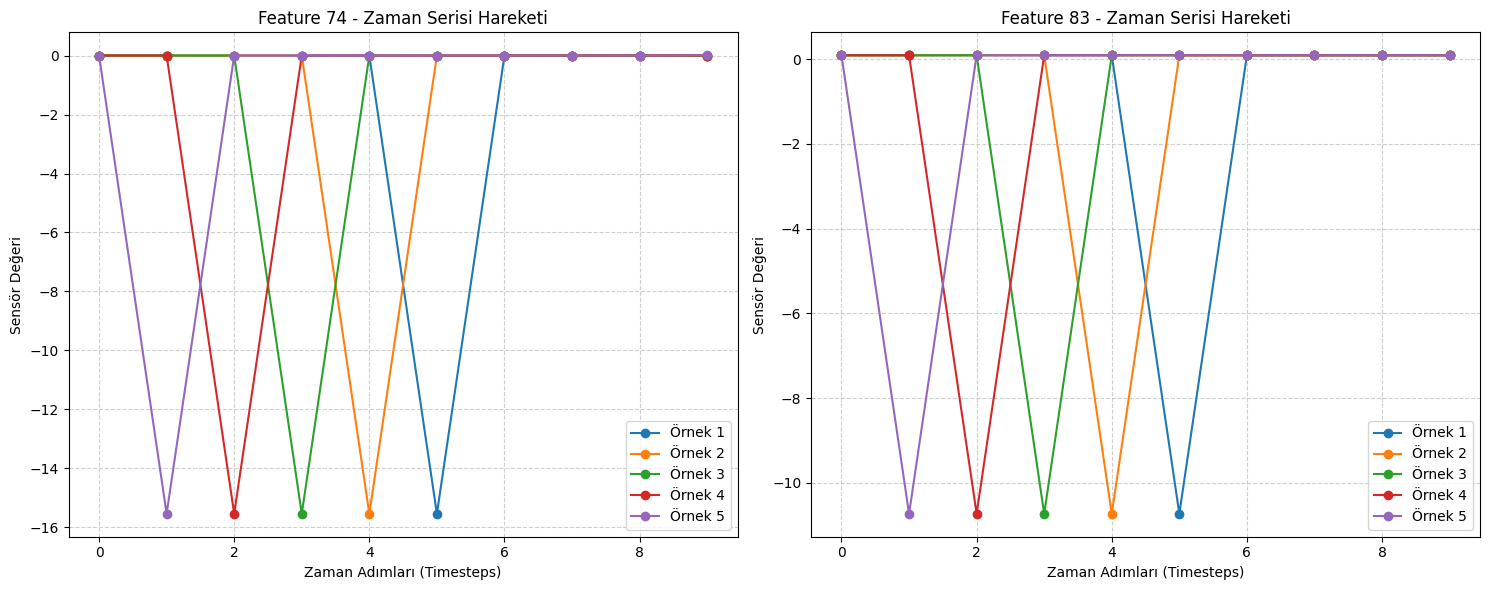

Bu grafiklerde ciddi bir veri kirliliği görülüyor. Sensörler normal çalışması sırasında aniden ikiside yakın negatif değerlere çökerek tekrardan aynı yerlerine geliyorlar.İki sensöründe aniden büyük yakın değerlere fırlaması fiziksel bir bağlantı kopması gibi problemin olduğuna dair ciddi bir işarettir. Karar alımı sırasında en ciddi etkiyi gösteren bu iki sensör için elimizde 3 yolla gidebiliriz.

1- Bu sensörleri eğitimden de analizden de çıkartıp bunlar olmadan tekrar eğitim yapabiliriz. Zaten çok sensörümüz var diye diğerlerdinden tespit yaparız.

2- Bu sensörlerin koptu yerlerdiki verileri ya komple temizleyebiliriz yada temizleyip yerlerine yapay veriler ekleyebiliriz.

3- Sensörlerin bu kopuş durumları da zaten bir anomalidir yani amacımız bunları da işin içine katarak tespit etmektir diyerek bu şekilde yolumuza devam ederiz.

Birinci seçenek ile devam edicez. Çünkü LSTM Autoencoder gibi ağır bir model zaten 131 özelliğimiz ile sürekli olarak hesaplama yapıyor. Şimdi bu iki sensördeki gibi diğerlerinden çok farklı bir anomali benzeri kopuş algıladığından buranın üzerinde çok ağır MSE hesaplamaları yapmak zorunda kalıp kalan 129 özelliği geri plana atabiliyor. Yeterince özelliğimiz olduğundan bu sensörler ile uğraşmak yerine diğer özellikleri ön plana çıkarmak efor açısından daha mantıklı olacaktır.

İkinci seçenek zaten çok uygun olmaz yapıtığımız proje türüne nazaran (anomali tespiti). Anomali sayılabilecek bir durumu yada veri yoksunluğunu normal verilermiş gibi ortalama yada benzeri yapay veri koyduğumuzda olmayanı hatta arananı kendi ellerimizle yanıltmış oluruz. 

Üçüncü seçenekte ise garipliği şöyle ifade edelim: sineği bozuka ile avlamaktır. Model üzerinde tekrar eğitim yada fine tuning yaptıktan sonra yeni güncellemelerde tekrar tekrar çalıştırınca bu işimize yaramayacak bariz belli olan ve diğer anomalileri tehlikeye atan durumları her seferinde belli olmasına rağmen tekrar hesaplamalarını yapmak zorunda kalacak sisteme ektra ciddi yük olacak.

Aynı şekilde Feature 116 ve 98'i de silersek bir şey kaybetmeyiz tam tersine diğer özelliklere daha çok odaklanacaktır.

In [ ]:
""" BOZUK SENSÖRLERİN TESPİTİ """
# df'den X'i oluştururken sildiğimiz o kolonları (timestamp, is_suspect vb.) çıkararak modelin tam olarak gördüğü o 131 kolonluk listeyi elde edicez
X_cols = df.drop(["timestamp", "is_suspect"]).columns

# Modelin gördüğü kolonların indekslerine göre hangi sensörlerin olduğunu yazdıralım. Bu indeksler, modelin girdi olarak kullandığı özelliklerin sırasına karşılık gelir.
print("Sileceklerimiz:")
print("1. Çöp (Eski 74) :", X_cols[74])
print("2. Çöp (Eski 83) :", X_cols[83])
print("3. Çöp (Eski 98) :", X_cols[98])
print("4. Çöp (Eski 116):", X_cols[116])

In [ ]:
""" SENSÖRLERİ SİLME """
# Gerçek suçluları (bozuk lag/diff özelliklerini) Polars ile veri setinden tamamen kazıyoruz
df = df.drop([
    "DV_pressure_diff_10min", 
    "Pressure_switch_lag_10min", 
    "Towers_lag_1h", 
    "Towers_lag_6h"
])

print(f"Sistem çöpleri temizlendi. Güncel veri boyutu: {df.shape}")

Sensörlerin indekslerini tespit ettik ve 4 sensörüde sildik.

In [ ]:
""" YENİ MODEL """
print("Yeni model üzerinden tahminler (reconstruction) alınıyor")

X_pred = autoencoder.predict(X_sample_seq)

# 3 boyutlu matrisin (samples, timesteps, features) MSE (Ortalama Karesel Hata) skorunu hesaplıyoruz
mse = np.mean(np.power(X_sample_seq - X_pred, 2), axis=(1, 2))

# Normal (0) ve Anomali (1) verilerinin hata skorlarını y etiketine göre ayırıyoruz
normal_mse = mse[y_sample_seq == 0]
anomali_mse = mse[y_sample_seq == 1]

# Sonuçları nesnel bir grafiğe döküyoruz
plt.figure(figsize=(12, 6))
plt.hist(normal_mse, bins=50, alpha=0.6, color='blue', label='Normal Durum (Düşük Hata Beklentisi)')
plt.hist(anomali_mse, bins=50, alpha=0.6, color='red', label='Anomali Durumu (Yüksek Hata Beklentisi)')

plt.title('Temizlenmiş Modelin Anomali Ayrıştırma Gücü (Reconstruction Error)')
plt.xlabel('Yeniden Yapılandırma Hatası (MSE)')
plt.ylabel('Frekans (Örnek Sayısı)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

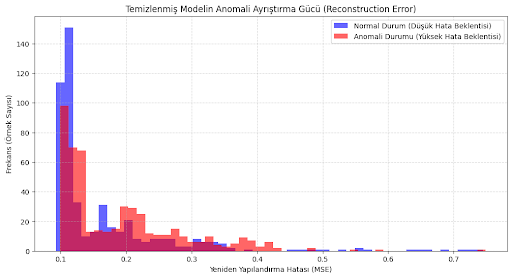

Bu grafik sorunlu sensörleri çıkardıktan sonra tekrar eğitmek yerine diğerleri ile işlem yaptığımızdan sorunu göstermektedir. Normalde anomaliler (kırmızı) sağa yapışık, normaller ise sola yapışık olacak şekilde çok büyük kısım ayrı olurlar ve sonrasında belirleyeceğimiz eşik değer ile net bir ayrım yaparız. Ancak burada ciddi problem olacka şekilde komple üst üste gelmiş durumdalar. Bu şekilde herhangi bir ayrım yapılamaz. Sorunlu sensörler maskeledik SHAP sorun yaşamasın ve tekrardan eğitim yapmamak için ancak keras dosyasında o verilerle eğitilmiş modelimiz olduğundan yine hata verdil. Yapılacak tek şey o sensörler olmadan tekrar eğitim yapmak.

EN BAŞTAN EĞİTİM

In [ ]:
""" VERİ OKUMA VE SORUNLU SENSÖR TEMİZLİĞİ"""
FEATURES_PATH = "/kaggle/input/datasets/denizbyat/new-train/metropt3_features.parquet"  
df = pl.read_parquet(FEATURES_PATH)

# Çöpleri en baştan siliyoruz
df = df.drop([
    "DV_pressure_diff_10min", 
    "Pressure_switch_lag_10min", 
    "Towers_lag_1h", 
    "Towers_lag_6h"
])
print(f"Temizlenmiş Veri: {df.shape[0]:,} satır, {df.shape[1]} sütun")

In [ ]:
# Feature kolonları (timestamp ve is_suspect hariç)
feature_cols = [col for col in df.columns if col not in ['timestamp', 'is_suspect']]

X = df.select(feature_cols).to_numpy()
y = df['is_suspect'].to_numpy()

# YEPYENİ bir Scaler eğitiyoruz (Çünkü kolon sayısı 127'ye düştü)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Scaler'ı ileride kullanmak üzere keydedicez sonrasında SHAP de graifk ve karşılaştırma için
with open("yeni_scaler_127.pkl", "wb") as f:
    pickle.dump(scaler, f)

# KRİTİK ADIM: Autoencoder SADECE normal veriyle (y==0) eğitilmelidir!
X_normal_scaled = X_scaled[y == 0]
print(f"Eğitim için ayrılan Normal Veri: {X_normal_scaled.shape}")

In [ ]:
timesteps = 10

def create_sequences(data, timesteps):
    sequences = []
    for i in range(len(data) - timesteps):
        sequences.append(data[i:i+timesteps])
    return np.array(sequences)

# Sadece normal verileri zaman pencerelerine bölüyoruz
X_train_seq = create_sequences(X_normal_scaled, timesteps)
print(f"Eğitim Sequence Boyutu: {X_train_seq.shape} -> Beklenen son boyut 127 olmalı")

In [ ]:
""" BELLEK DOSTU (JENERATÖRLÜ) LSTM AUTOENCODER MODEL EĞİTİMİ """
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input
from tensorflow.keras.utils import Sequence

# Jeneratör Sınıfı - verinin tamamını bir kerede GPU ya yüklemek yerine, sadece o an işlenecek olan "batch" kadarını belleğe çağırır
class KerasBatchGenerator(Sequence):
    def __init__(self, data, batch_size=256):   # her seferinde gelecek veri = 256
        self.data = data
        self.batch_size = batch_size

    def __len__(self):  # her epoch da kaç adım atacağını (diskten kaç kere veri geleceğini) belirler
        return int(np.ceil(len(self.data) / float(self.batch_size)))

    def __getitem__(self, idx):     # her adımda çalışıp veriden bir dilim alır ve bunu (input, target) çifti olarak döndürür
        # Sadece o anki adımı GPU'ya gönderiyoruz (Maksimum 2-3 MB)
        batch_x = self.data[idx * self.batch_size : (idx + 1) * self.batch_size]
        return batch_x, batch_x # Autoencoder olduğu için hedef de girdiyle aynı olur

# sekans Jeneratör kullandığımız için Keras'ın 'validation_split' özelliği çalışmaz
# O yüzden veriyi eğitim (%90) ve doğrulama (%10) olarak manuel bölüyoruz
split_idx = int(len(X_train_seq) * 0.9)
train_data = X_train_seq[:split_idx]
val_data = X_train_seq[split_idx:]

# Eğitim ve doğrulama için iki ayrı jeneratör nesnesi oluşturulmuş. Bu sayede eğitim sırasında GPU sadece ihtiyaç duyduğu küçük paketleri işler
train_gen = KerasBatchGenerator(train_data, batch_size=256)
val_gen = KerasBatchGenerator(val_data, batch_size=256)


# zaman serisi verilerindeki gizli desenleri öğrenmek ve veriyi sıkıştırıp tekrar açmak (reconstruction) için
print("Model mimarisi (127 özelliğe göre) inşa ediliyor")
model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),     # Giriş katmanı. Zaman adımı (timesteps) ve özellik sayısını (127 özellik) tanımlar.
    LSTM(64, activation='relu', return_sequences=False),    # (Encoder): Veriyi 64 birimlik bir "bağlam vektörüne" sıkıştırır. return_sequences=False olduğu için sadece dizinin en sonundaki özet bilgiyi verir.
    RepeatVector(X_train_seq.shape[1]),     # Encoder'dan çıkan tek bir özeti, orijinal zaman adımı sayısı kadar kopyalar. Böylece Decoder katmanı için uygun boyuta geri döner.
    LSTM(64, activation='relu', return_sequences=True), # (Decoder): Sıkıştırılmış bilgiden orijinal diziyi tekrar inşa etmeye başlar.
    TimeDistributed(Dense(X_train_seq.shape[2]))    #Her bir zaman adımı için ayrı ayrı çıktı üretir. Çıkış katmanındaki nöron sayısı, giriş katmanındaki özellik sayısı (127) ile aynıdır
])

model.compile(optimizer='adam', loss='mse') # Ortalama Kare Hata. Modelin amacı girişi aynen geri üretmek olduğu için, orijinal veri ile üretilen veri arasındaki farkın karesini minimize eder

# Eğer val_loss (doğrulama kaybı) 3 epoch boyunca iyileşmezse eğitimi durdurur. Bu, modelin ezberlemesini (overfitting) engeller
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20, 
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
    # true : Eğitim durduğunda, kaybın en düşük olduğu (en iyi) ağırlıkları geri yükler.
)

model.save("yeni_temiz_lstm_autoencoder.keras")
print("Model başarıyla eğitildi ve kaydedildi ✓")

Bu eğitimde ekstra olarak KerasBatchGenerator (Veri Jeneratörü) kullandık. buna sebep olan şey kaggle kotamız oldu. RAM ve GPU boyutumuz yetersiz kaldığından jenaratör ihtiyacı doğru. Burada ki mantık sınıfta 3 eleman oluşturduk gibi düşünülebilir. init - kuralların belirlendiği kısım, len - verilerimizi belirlediğimiz boyutta her seferinde git,geli yapan hesaplayan kısım, getitem - gelen veriyi işleten ve çıkartan kısım olacak. Bu sayede ram şişmez işlemler part part yapılır. 

Girdi ve çıktının aynı olmasının sebebi modelimizden kaynaklıdır. Sonuçta encoder model olduğundan girdi ile çıktı aynı olmalıdır

In [ ]:
""" GRAFİKLEŞTİRME VE ANOMALİ TESPİTİ """ 
print("Yeni 127 özellikli veriden test örneklemi çekiliyor...")
# Anomali ve normal örneklem al (Yeni X_scaled ve y üzerinden)
anomali_idx = np.where(y == 1)[0][:500]
normal_idx = np.where(y == 0)[0][:500]
sample_idx = np.concatenate([normal_idx, anomali_idx])

X_sample = X_scaled[sample_idx]
y_sample = y[sample_idx]

# Sequence oluştur
X_sample_seq = create_sequences(X_sample, timesteps)
y_sample_seq = y_sample[timesteps:]

print(f"Test örneklemi hazır: {X_sample_seq.shape}")
print("Yeni model üzerinden tahminler (reconstruction) alınıyor...")

# Temiz modelimizle tahmin yapıyoruz
X_pred = model.predict(X_sample_seq)

# MSE (Ortalama Karesel Hata) skorunu hesaplıyoruz
mse = np.mean(np.power(X_sample_seq - X_pred, 2), axis=(1, 2))

# Normal ve Anomali hatalarını ayırıyoruz
normal_mse = mse[y_sample_seq == 0]
anomali_mse = mse[y_sample_seq == 1]

# Sonuçları grafiğe döküyoruz
plt.figure(figsize=(12, 6))
plt.hist(normal_mse, bins=50, alpha=0.6, color='blue', label='Normal Durum (Beklenen: Düşük Hata)')
plt.hist(anomali_mse, bins=50, alpha=0.6, color='red', label='Anomali Durumu (Beklenen: Yüksek Hata)')

plt.title('Sıfırdan Eğitilen Temiz Modelin Anomali Ayrıştırma Gücü')
plt.xlabel('Yeniden Yapılandırma Hatası (MSE)')
plt.ylabel('Frekans (Örnek Sayısı)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

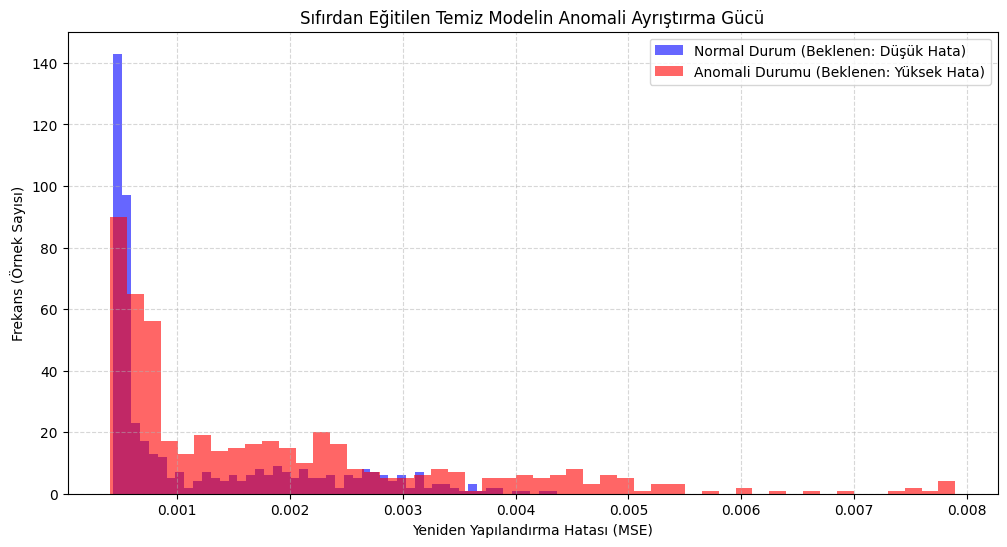

Sonuç bir önceki model ile ciddi derece de aynı ancak çok çok önemli bir fark olması gereken anomali durumlarından çok azı da olsa sağ tarafa geçmiş. Önceki modelde olmayan bu büyük fark modelimizin  aslında doğru tahmin ettiği yani düzgün çalıştı durumlarında olduğunu gösteriyor. Ancak dediğimiz gibi yine normal ve anormal durumlar ciddi iç içe olduğundan eşik değer ayrımında problemler ile karşılaşıcaz. 

Şimdi yapacağımız şey şu olacak : grafiğin sağ tarafında kalan, mavi kısımlar ile çakışmayan yada çok az çakışan kısmları direkt modelinde bulduğu gibi eşik değer ile ayırım o kısmı direkt anomali olarak kabul edeceğiz ve bu kısımların üzerine giderek nedenlerini araştıracağız. Bunuda yine SHAP ile kök neden analizi (root cause analysis) yapacağız

In [ ]:
""" SEKANS PARÇALAMA VE EŞİK DEĞER BELİRLEME """
import shap
# Zaman penceresi (anomali tespiti için geçmişteki kaç zaman adımını kullanacağımızı belirler)
timesteps = 10
# ram dostu sadece anomali etiketli veriler için sequence oluşturan fonksiyon
def create_sequences_by_indices(data, indices, timesteps):
    sequences = []
    valid_indices = []
    for i in indices:
        if i >= timesteps:
            sequences.append(data[i-timesteps:i])   # Sadece anomali etiketli veriler için zaman pencereleri oluşturuyoruz
            valid_indices.append(i) # Orijinal satır numarasını SHAP için saklıyoruz
    return np.array(sequences), np.array(valid_indices)

print("Sadece anomali etiketli (y=1) veriler için sequence oluşturuluyor...")
anomali_idx = np.where(y == 1)[0]      # Tüm anomali indekslerini alıyoruz
X_anomali_seq, valid_anomali_idx = create_sequences_by_indices(X_scaled, anomali_idx, timesteps)    
# Sadece anomali etiketli veriler için zaman pencereleri oluşturuyoruz ve bu pencerelerin orijinal satır numaralarını saklıyoruz ki SHAP analizinde bu bilgiyi kullanabilelim

print("Temiz model üzerinden bu anomalilerin MSE (Hata) skorları hesaplanıyor...")
# Kilitlenmemesi için batch_size ekliyoruz (parça parça tahmin yaparak belleği yönetiyoruz)
X_pred_anomali = autoencoder.predict(X_anomali_seq, batch_size=256)     # Sadece anomali etiketli veriler için tahmin yapıyoruz. Bu tahminler, her pencere için modelin yeniden yapılandırdığı veriyi verecek
mse_anomali = np.mean(np.power(X_anomali_seq - X_pred_anomali, 2), axis=(1, 2))
# modelin orijinal veri ile kendi ürettiği veri arasındaki farkın karesi hesaplanıyor. Autoencoder "normal" veriyi çok iyi tanır. 
# Eğer karşısına gerçek bir anomali gelirse, onu yeniden inşa ederken çok hata yapar (yüksek MSE).

# Markdown notunda karar verdiğimiz o bıçak sırtı eşik değeri
THRESHOLD = 0.0015

# Sadece bu eşiği aşan (sağa uzanan kuyruktaki) kesin anomalileri filtrele
kesin_anomali_mask = mse_anomali > THRESHOLD
kesin_anomali_seq = X_anomali_seq[kesin_anomali_mask]
kesin_anomali_gercek_idx = valid_anomali_idx[kesin_anomali_mask]

print("-" * 50)
print(f"Veri setindeki toplam etiketli anomali sayısı (y=1): {len(anomali_idx)}")
print(f"Modelin Threshold ({THRESHOLD}) üzerinde KESİN YAKALADIĞI anomali sayısı: {len(kesin_anomali_seq)}")

Ram çık sıkışmaması için yine sekanslı olarak ilerledik. üstteki grafikde göründüğü üzere sadece kırmızı yani y=1 etiketli değerleri aldık. Normal etiketlerin aniden ciddi azaldığı kısımdan itibaren eşik değerini belirledik ve sonrasında kalan yüksek mse değerli anomalileride ayırdık. Toplamda - Veri setindeki toplam etiketli anomali sayısı (y=1): 101595
Modelin Threshold (0.0015) üzerinde KESİN YAKALADIĞI anomali sayısı: 56826 olarak sonuç verdi. Şimdi bu 56bin eşiği aşan anomali durumu içerisinden en yüksek MSE değerli ilk 500 durumu inceleyerek hangi sensörün ne kadar etikisine bakacağız sonrasından kesin uyuşma olması için yine anomaliler içinden rastgele 100 örnek seçip SHAP analizi yapcvağız.

In [ ]:
""" ANOMALİLERİN SIRALANMASI VE TEST HAVUZLARININ OLUŞTURULMASI """
# Sadece Threshold'u geçen kesin anomalilerin MSE skorlarını alıyoruz
kesin_mse = mse_anomali[kesin_anomali_mask]

# Skorları büyükten küçüğe sıralamak için indeksleri al
sorted_indices = np.argsort(kesin_mse)[::-1]

print("Anomaliler MSE skorlarına göre sıralanıyor ve TOP 500 alınıyor")
# 1. TEST HAVUZU: Top 500 Ekstrem Anomali
top_500_idx = sorted_indices[:500]
top_500_seq = kesin_anomali_seq[top_500_idx]

print("Rastgele Test: Havuzdan rastgele 100 anomali seçiliyor")
# 2. TEST HAVUZU: Rastgele 100 Anomali
rng = np.random.default_rng(seed=42) # Sonuçların her çalışmada aynı çıkması (tekrar edilebilirlik) için
random_100_idx = rng.choice(len(kesin_anomali_seq), size=100, replace=False)
random_100_seq = kesin_anomali_seq[random_100_idx]

print("-" * 50)
print(f"1. Test Seti (Top 500) Hazır Boyut: {top_500_seq.shape}")
print(f"2. Test Seti (Rastgele 100) Hazır Boyut: {random_100_seq.shape}")

Anomaliler MSE değerlerine göre sıralanıp dediğimiz gibi 2 test havuzuna ayrıldı

In [ ]:
""" 2 AYRI SHAP ANALİZİ """
print("SHAP'in anlayabilmesi için 'MSE Sarmalayıcı Model' (Wrapper) oluşturuluyor...")
# Autoencoder'ın 3D çıktısını, SHAP'in istediği tek boyutlu MSE (Hata) skoruna dönüştürüyoruz
inputs = tf.keras.Input(shape=(10, 127))    # girdi
reconstructions = autoencoder(inputs)   # çıktı - modelin yeniden yapılandırdığı veri

# Keras Lambda katmanı ile MSE hesaplayıp tek bir değere (vektör) indirgeyen fonksiyon (SHAP'in istediği formatta)
def get_mse(args):
    x, x_pred = args
    mse = tf.reduce_mean(tf.square(x - x_pred), axis=[1, 2])     # MSE değeri hesaplanır (her pencere için tek bir skor)
    return tf.reshape(mse, (-1, 1)) # SHAP'in istediği 2D format (batch_size, 1)

mse_output = tf.keras.layers.Lambda(get_mse)([inputs, reconstructions])
mse_model = tf.keras.Model(inputs=inputs, outputs=mse_output) 
# Yeni modelimiz: Girdi olarak diziyi alıyor, çıktı olarak sadece MSE skorunu veriyor


print("SHAP için 'Normal' (y=0) verilerden 100 adet referans seçiliyor...")
normal_idx = np.where(y == 0)[0]    # sadece normalleri alıyoruz ki doğruları bilsin ona göre yanlışları tespit edebilsin
rng_bg = np.random.default_rng(seed=42)
bg_idx = rng_bg.choice(normal_idx, size=100, replace=False)     # 100 örnek seçiliyor
background_seq, _ = create_sequences_by_indices(X_scaled, bg_idx, 10)


print("GradientExplainer MSE Modeli ile başlatılıyor...")
# DİKKAT: Artık autoencoder'ı değil, MSE üreten mse_model'i veriyoruz!
explainer = shap.GradientExplainer(mse_model, background_seq)
# gradyanları (türevleri) takip ederek, girişteki her bir hücrenin (10x127) nihai MSE skorunu ne kadar artırdığını veya azalttığını hesapla

# test 1 
print("Top 500 Ekstrem Anomali için SHAP değerleri hesaplanıyor")
shap_values_top500 = explainer.shap_values(top_500_seq)
print("Top 500 için SHAP matematiksel analizi başarıyla tamamlandı ✓")

# test 2
print("Rastgele 100 Kontrol Testi için SHAP değerleri hesaplanıyor")
shap_values_random100 = explainer.shap_values(random_100_seq)
print("Rastgele 100 için SHAP matematiksel analizi de başarıyla tamamlandı ✓")
print("İşlemler Tamamlandı ✓")

SHAP analizi yapılırken bu analiz için tek bir metoda odaklanması gerekir. Bunuda wrapper dediğimiz sarmalayıcı sayesinde oluştururuz. Burada mantık şöyle: SHAP isterki ona bir değer ver o değeri çıkartan sonuçları analiz etsin. Bu sonucun alınmasında nelerin ağırlıklı rolü olduğunu. Wrapper yapılmaz ise AssertionError alınır yani buda odaklanıcak bir değer değilde bir çok değer olduğunu söyle. Kısaca bizim 3 boyutlu olan girdimizi tek boyuta indirerek SHAP e veriyoruz. Bu boyut ezme işlemi orjinal çıktımızda değil sadece SHAP tek değer üzerinden analiz edebildiği için ona özel ezme işlemi yapıyoruz

Elimizde 2 test havuzu şeklinde - (500 anomali x 10 zaman adımı x 127 sensör) - ilk 500 ve (100 anomali x 10 zaman adımı x 127 sensör) - rastgele 100 var yani yine çıktılarımız girdi boyutu kadarorjinalinde 3 boyutlu olacak SHAP sadece tek değer üzerinden hesaplama yapabildiği için ona özel ezme yapmıştık

In [ ]:
""" BOYUT DÜZENLEME VE GRAFİKLEŞTİRME """
print("Zaman serisi boyutları (3D -> 2D) ezilerek ortalaması alınıyor")

# SHAP TF çıktıları list formatında dönebilir, güvenli bir şekilde matrisi alıyoruz
shap_500 = shap_values_top500[0] if isinstance(shap_values_top500, list) else shap_values_top500
shap_100 = shap_values_random100[0] if isinstance(shap_values_random100, list) else shap_values_random100

# 10 birimlik zaman adımlarının (axis=1) ortalamasını alarak 2D'ye düşürüyoruz
shap_500_2d = np.mean(shap_500, axis=1)
shap_100_2d = np.mean(shap_100, axis=1)

# Aynı işlemi orijinal matrislere de yapıyoruz (Grafikte yüksek/düşük değerleri renklendirmek için)
X_top500_2d = np.mean(top_500_seq, axis=1)
X_random100_2d = np.mean(random_100_seq, axis=1)

print("\n--- 1. TEST: TOP 500 EKSTREM ANOMALİ KÖK NEDENLERİ ---")
plt.figure(figsize=(10, 6))
# En çok etki eden ilk 15 sensörü çizdiriyoruz
shap.summary_plot(shap_500_2d, X_top500_2d, feature_names=feature_cols, max_display=15, show=True)

print("\n--- 2. TEST: RASTGELE 100 KONTROL TESTİ KÖK NEDENLERİ ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_100_2d, X_random100_2d, feature_names=feature_cols, max_display=15, show=True)

Şimdi orjinal çıktının boyutuda ezerek summaryplot grafiğine uygun hala getiriyoruz. 

ÇIKTI:

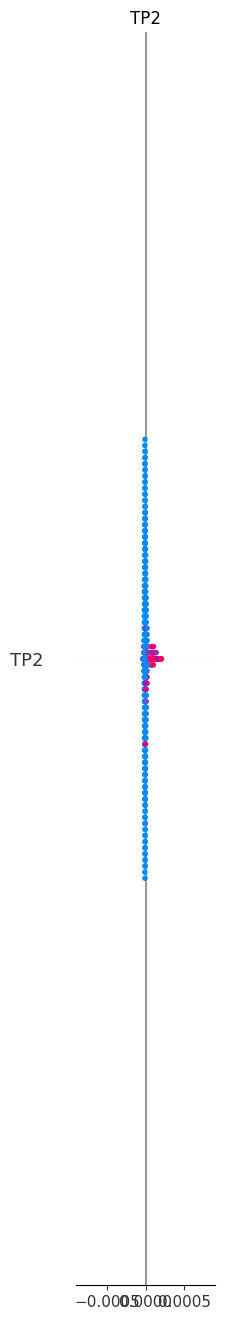 - 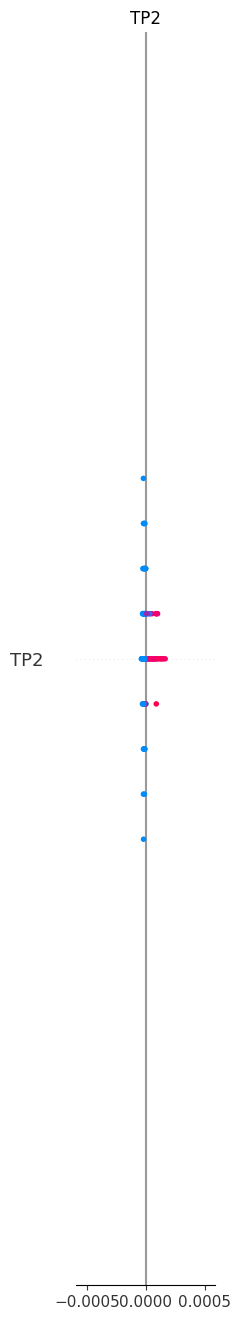

Koskoca 127 sensör içinden SHAP grafiğinde sadece ve sadece TP2 çıkmış. kodda max_display= 15 yapmıştık en etkili olan ilk 15 sensörü yazdırdık ancak tp2 diğerlerinden o kadar net ve yüksek ayrılmışki diğerleri neredeyse sıfır. TP2 kompresör basıncından sorumlu sensördür. İncelediğimiz veri seti zaten basınç sistemlerinin en ön planlarda olduğu sistemdir. Bir pnömatik sistemde (hava basıncıyla çalışan tren kapıları vb.) yaşanan anomalilerin %90'ı hava kaçakları, valf yırtılmaları veya kompresör arızalarıdır. Makine arıza verdiğinde (anomali yaşandığında), modelin hatayı doğrudan kompresör basıncındaki (TP2) olağandışı hareketlerden yakalaması %100 fiziksel ve mekanik bir gerçektir.

Hem en şiddetli Top 500 arızanın hem de sıradan Rastgele 100 arızanın grafiği birebir aynı sonucu verdi. İkisi de TP2'yi işaret ediyor. 127 özelliin SHAP analizinden sadece tp2 çıkmaı diğer tüm özelliklerin neredeyse sıfıra yakın yani önemsiz olduğu anlamına geliyor. Anomalilerde en büyük suç TP2 sensörü olarak kayıtlara geçiyoruz. Bundan sonra TP2 sensörünü orjinal ham veri setimizden zaman serisi grafikleri ile dikkatli bir şekilde inceleyeceğiz. sensör fiziksel olarak ne yapıyor? Basınç aniden sıfıra mı düşüyor, yoksa çok mu yükseğe fırlıyor? gibi durumlarını değerlendircez.

In [ ]:
""" TP2 SENSÖR İNCELEMESİ """
# Sadece TP2 basıncı ve anomali etiketlerini Numpy dizisine çeviriyoruz
tp2_data = df['TP2'].to_numpy()
y_labels = df['is_suspect'].to_numpy()

print("Arıza anı tespit ediliyor ve TP2 grafiği çiziliyor")
# İlk büyük arızanın olduğu noktayı bul
anomali_idx = np.where(y_labels == 1)[0]   # Anomali etiketli noktaların indekslerini alıyoruz
ilk_ariza_merkezi = anomali_idx[0]  # İlk arızanın merkezi olarak ilk anomali indeksini alıyoruz. Bu, TP2 grafiğinde arızanın tam olarak nerede başladığını göstermek için kullanılacak.

# Olayı net görmek için arızadan önceki 500 ve sonraki 500 adımı alıyoruz (Yakın çekim)
baslangic = max(0, ilk_ariza_merkezi - 500)
bitis = min(len(tp2_data), ilk_ariza_merkezi + 500)

plt.figure(figsize=(14, 6))
# Tüm zaman penceresini mavi çizgiyle çiz
plt.plot(range(baslangic, bitis), tp2_data[baslangic:bitis], label='TP2 Ham Basınç Değeri', color='dodgerblue', linewidth=1.5)

# Arızalı anları (y=1) kırmızı noktalarla işaretle
arizali_x = [i for i in range(baslangic, bitis) if y_labels[i] == 1]
arizali_y = [tp2_data[i] for i in range(baslangic, bitis) if y_labels[i] == 1]
plt.scatter(arizali_x, arizali_y, color='red', label='Anomali (Arıza) Etiketi', zorder=5, s=20)

plt.title("Gerçek Dünyada TP2 (Kompresör Basıncı) Arıza Anı Hareketi")
plt.xlabel("Satır İndeksi (Zaman)")
plt.ylabel("Basınç (Ham Değer)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

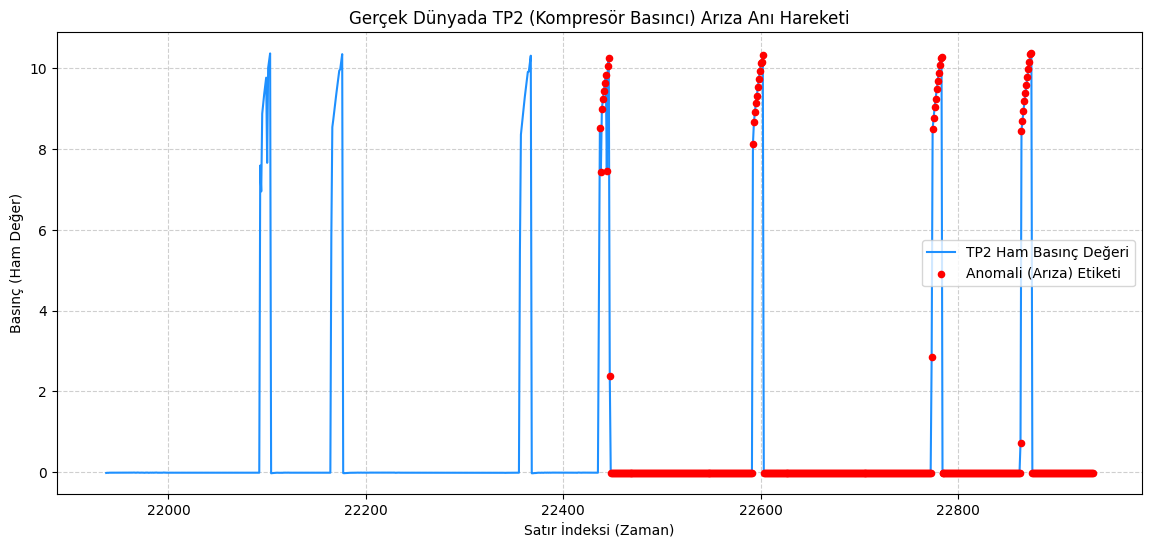

Çıktıda ciddi tutarsızlık var. Bir anomali gözüküyor ancak sonrasında tekrar önceki örüntü gibi normal seyrettiğinde bile anomali vermeye devam ediyor. üstelik 0 olduğunda durmadan deli gibi anomali veriyor. Bunun sebepleri diğer sensörlerden kaynaklıda olabilir yada gerçektende tp2 hava basarken hava kaçağı gibi gerçek bir anomalide olabilir önce bunu kontrol etmemiz lazım ondan eğer herhangi bir sorun yoksa boş bir anomali ise sonrarasında bu zaman dilimindeki tp2 ile bağlantısı olmayan diğer sensörlere bakabiliriz.

Bunun gerçekliğini  tp2 ile koordineli çalışan tp3 sensörünü kontrol ederek bulucaz. Sistemde tp2 havayı tp3 basıyor şeklinde çalışmaktadır. yani tp2 her tepe yaptığında tp3 de hava miktarı artmalıdır. Bundan dolayı tp2 ile tp3 ün uyum durumuna bakacağız anomali zamanında.

In [ ]:
# 22800 civarında pencere açacağız yakın çeki için
baslangic = 22500
bitis = 23100

tp2_data = df['TP2'].to_numpy()[baslangic:bitis]
tp3_data = df['TP3'].to_numpy()[baslangic:bitis]  # TP3: Sistemin Ana Hava Tankı
y_labels = df['is_suspect'].to_numpy()[baslangic:bitis]     
# Bu aralıkta TP2'nin hareketini TP3'ün hareketiyle karşılaştırarak fiziksel bir ispat yapacağız. Eğer TP2 normal görünürken TP3'te büyük bir dalgalanma varsa, bu bize TP2'nin tek başına değil, sistemin genelinde bir sorun olduğunu gösterecektir.
x_axis = range(baslangic, bitis)    # 

fig, ax = plt.subplots(figsize=(14, 6))

# TP2 ve TP3'ü fiziksel etkileşimi görmek için aynı anda çiziyoruz
ax.plot(x_axis, tp2_data, label='TP2 (Kompresör Basıncı)', color='dodgerblue', linewidth=2)
ax.plot(x_axis, tp3_data, label='TP3 (Ana Tank Basıncı)', color='darkorange', linewidth=2, alpha=0.8)

# Sadece anomali denilen yerleri kırmızı nokta yapıyoruz
arizali_x = [x_axis[i] for i in range(len(y_labels)) if y_labels[i] == 1]
arizali_y = [tp2_data[i] for i in range(len(y_labels)) if y_labels[i] == 1]
ax.scatter(arizali_x, arizali_y, color='red', label='Anomali Uyarısı (Yapay Zeka)', zorder=5, s=30)

ax.set_title("Fiziksel İspat: 22800'de Kompresör (TP2) Normal Görünürken Ana Tank (TP3) Ne Yapıyor?")
ax.set_xlabel("Satır İndeksi (Zaman)")
ax.set_ylabel("Basınç (Ham Değer)")
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

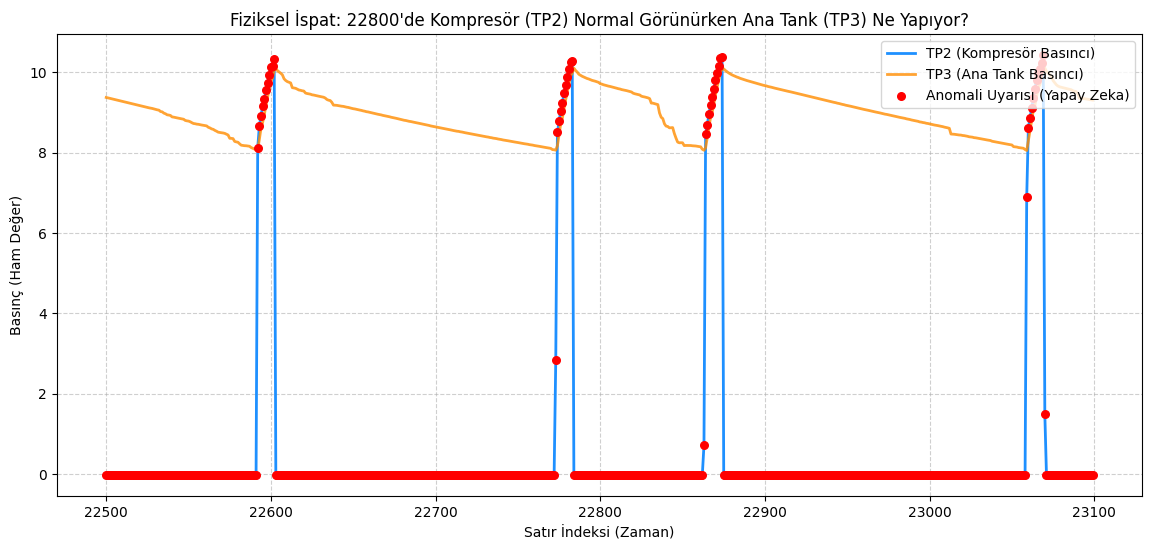

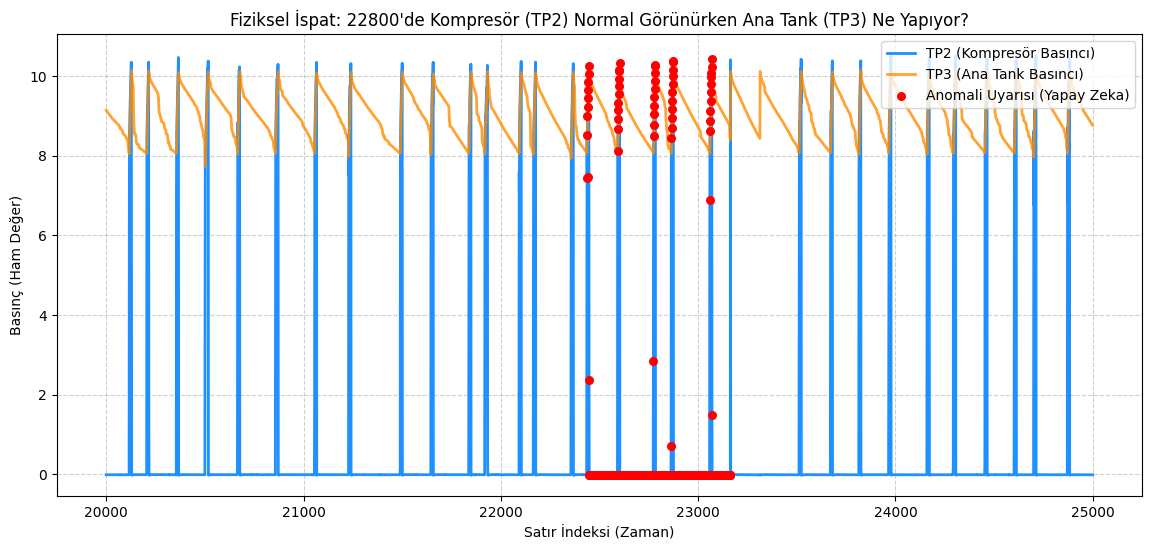

Burada tp3 tankındaki hava basıncı sürekli olarak düşüyor. Düşüş her 8 değerine yaklaştığında tp2 tekrardan hava basıyor ve tp3 tankını doldurmaya çalışıyor. Veri setimiz gerçek bir metro treninin pnömatik fren ve kapı sisteminden alınmıştır. Bu sistemlerdeki ana hava tankları (TP3) ve kompresör (TP2) mekaniği katı uluslararası standartlara (UIC ve EN normları) tabi olduğundan gerçek çalışma hali durumunda çalıştığını söylüyor. Sistem 8 bara kadar izin vermektedir ve 2. resim daha büyük zaman serisine bakınca normal denilen durumlarda da aynı örüntü ve sayısal değerler aralığında olduğu görülüyor bundan dolayı model büyük bir hata yapmıştır.

Model zaman serisi tahmin modellerinde çok sık rastlanan (özellikle LSTM'de) çok sık düşülen "Overfitting to Time" (Zamana Aşırı Uyum) tuzağına düştü. zaman serisinin ritmini ezberlemiş ve ufacık bir faz kaymasında (kompresör olması gerekenden 3 saniye geç çalıştı diye) panikleyip sistemi arızalı ilan etmiş.

Bundan sonra 3 yol izleyebiliriz: 1- veri mühendisliğine dönüş (zaman serileri yerine sensörlerin örüntülerini öğretip baştan inşa edebiliriz), 2- dinamik eşik (Muvcut MSE skoru yerine belli bir zamandaki skorları baz alarak alrm veren sistem gibi), 3- algoritmayı değiştirme (eriyi saniyelere göre değil şekilsel benzerliğe göre eşleştiren Dynamic Time Warping (DTW) yaklaşımına geçip ağaç tabanlı algoritma kurma)

Modele son bir şans daha verip 2. yol ile devam edeceğim

In [ ]:
""" 2.BÖLÜM - YALANCI ALARMLARI FİLTRELEME VE DİNAMİK EŞİK BELİRLEME """
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
import tensorflow as tf

print("Temiz GPU üzerinde RAM dostu Chunking (Parçalama)")
timesteps = 10      # modelin tahmin için baktığı pencere boyutu
total_sequences = len(X_scaled) - timesteps     # Toplam sequence sayısı (veri uzunluğundan timesteps kadar eksik çünkü her sequence 10 adım içeriyor)
chunk_size = 50000  # Güvenli lokma boyut   u
mse_all = []
indices = np.arange(total_sequences)

# lokmaları döndürecek döngü
for i in range(0, len(indices), chunk_size):
    chunk_indices = indices[i : i + chunk_size]
    seq_chunk = np.array([X_scaled[j : j + timesteps] for j in chunk_indices])  # lokmalar 3d yapı ile modele verilecek
    # GPU'da sorunsuz ve hızlı çalışması için batch_size 512 yani lokmaları 512şerli gruplar halinde işleyecek. verbose=0 ile gereksiz log kalabalığı önlemek için.
    pred_chunk = autoencoder.predict(seq_chunk, batch_size=512, verbose=0)
    
    # Hata skorlarını hesaplaması yani giriş verisi ile modelin tahmin ettiği veri arasındaki farkın karesi)
    mse_chunk = np.mean(np.power(seq_chunk - pred_chunk, 2), axis=(1, 2))
    mse_all.extend(mse_chunk)
    
    # GPU ve RAM'deki çöpü anında temizliyoruz ki sistem şişmesin (tensorflow'un GPU belleği yönetimi bazen yetersiz kalabiliyor, bu yüzden manuel müdahale gerekiyor)
    del seq_chunk, pred_chunk, mse_chunk
    gc.collect()
    tf.keras.backend.clear_session() 
    
    print(f"İşlenen: {i + len(chunk_indices)} / {total_sequences} satır tamamlandı...")

mse_all = np.array(mse_all)     #Tüm lokmalar işlendiğinde, mse_all listesi tüm veri seti için MSE skorlarını içerecek şekilde birleşmiş olacak
print("Tüm verinin hesaplaması çökme yaşanmadan başarıyla tamamlandı ✓")
print("Hareketli Ortalama Tolerans Filtresi Uygulanıyor...")
mse_series = pd.Series(mse_all)     # Pandas Series'e dönüştürerek hareketli ortalama (rolling mean) uygulamak daha kolay olacak. Bu, modelin anlık paniklerini (geçici yüksek MSE değerlerini) yumuşatacak ve gerçek anomalileri daha net ortaya çıkaracak.


# 50 adımlık tolerans penceresi 
# (Modelin anlık paniklerini ezecek çünkü MSE çok titreşimlidir anlık önemsiz dalgalanmalarıda hesaba katacağından tutarsızlığı azaltır ve gerçek anomalilerin daha net görünmesini sağlar)
window_size = 20 
smoothed_mse = mse_series.rolling(window=window_size).mean().fillna(mse_series.mean())  
# Hareketli ortalama uygulanır. İlk 49 değer NaN olacağı için fillna(0) ile sıfırla dolduruyoruz (2.aşamada ortalma ile doldurduk) (Bu, grafikteki ilk bölümü etkileyebilir ama genel trendi görmemizi sağlar)

# Yeni dinamik eşik: Filtrelenmiş skorların en üst %0.1'lik kısmı yani 99.9'luk kısmı eşik olarak alıyoruz. Bu, modelin normalde gördüğü hataların çok üstünde olan gerçek anomalileri yakalamamızı sağlar.
# THRESHOLD_NEW = np.percentile(smoothed_mse, 99.9)   # normalde direkt sayısal değer veriyorduk
# GÜNCELLEME: Eşik değerini sadece yüzdeye göre değil, aynı zamanda ortalama ve standart sapmaya göre de belirleyelim. Bu, verinin dağılımına daha duyarlı bir eşik sağlar.
multiplier = 2.5 # Standart sapmanın kaç katı kadarını eşik olarak kullanacağımızı belirler. Bu değeri artırmak, daha az ama daha kesin anomaliler yakalamamızı sağlar. Azaltmak ise daha fazla ama bazı yanlış alarmlara da yol açabilir.
THRESHOLD_NEW = smoothed_mse.mean() + (multiplier * smoothed_mse.std())     # threshold = u + (N x sigma)
print(f"Yeni Dinamik Eşik (Z-Score): {THRESHOLD_NEW:.6f}")
print(f"Ortalama Hata: {smoothed_mse.mean():.6f}")
print(f"Standart Sapma: {smoothed_mse.std():.6f}")


print("Karşılaştırma Grafiği Çiziliyor...")
plt.figure(figsize=(14, 6))
start_idx = 20000
end_idx = 35000
# Eski hatalı panikler yani gürültüler gri renk
plt.plot(range(start_idx, end_idx), mse_series.values[start_idx:end_idx], label='Ham MSE (Anlık Panikler/Yalancı Alarm)', alpha=0.4, color='gray')
# Yeni akıllı tolerans filtrelenmiş hatalar kırmızı renk
plt.plot(range(start_idx, end_idx), smoothed_mse.values[start_idx:end_idx], label=f'Filtrelenmiş Toleranslı MSE (Pencere={window_size})', color='red', linewidth=2)
# Yeni sınırımız mavi kesikli çizgi
plt.axhline(THRESHOLD_NEW, color='blue', linestyle='--', label=f'Yeni Dinamik Eşik ({THRESHOLD_NEW:.4f})')

plt.title(f"Yalancı Alarmları (False Positive) Filtreleme ve Dinamik Eşik (İndeks: {start_idx}-{end_idx})")
plt.xlabel("Satır İndeksi (Zaman)")
plt.ylabel("Hata Skoru (MSE)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Burada kısaca diğer işlemlerden farkı autoencoder modelimizin sonuçlarını akıllandırıyoruz. Sadece büyük veriyi güvenli bir şekilde işlemekle kalmıyor, aynı zamanda sistemin her küçük sapmada alarm vermesini engelleyerek sadece kalıcı ve ciddi hataları raporlamasını sağlıyoruz.

ÇIKTI:

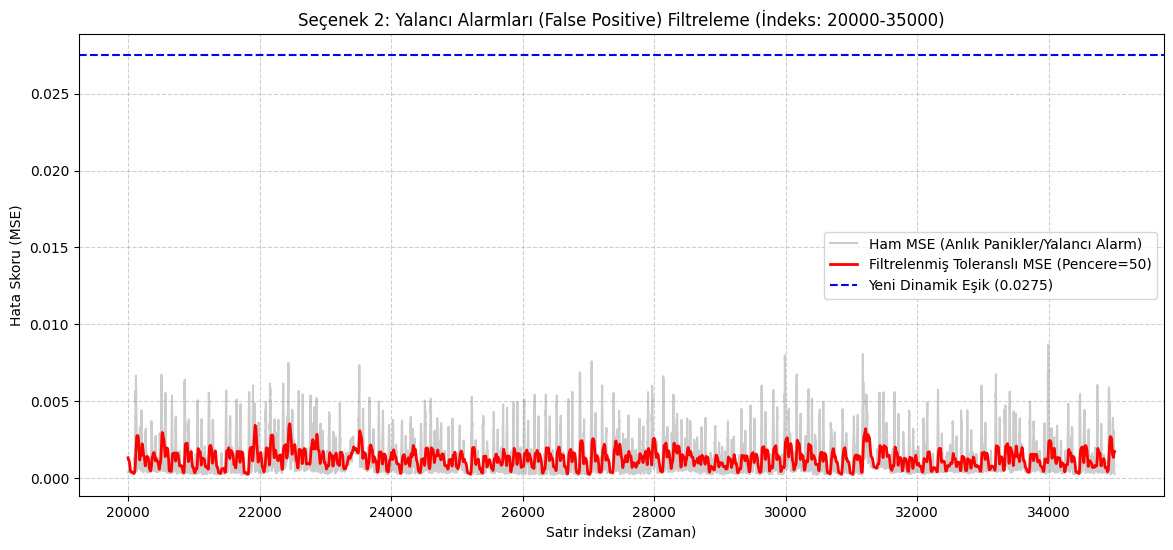

grafikte gürültüleri engellemek için yaptığımız filtreleme iyi çalışmış görünüyor ancak veri setimiz çok temiz olduğunda yani anomali sayımız ciddi az oldundan %0.1 eşik biraz abartı yapmışız ayrıca gürültüyü ezerken pencereyide biraz küçültmemizde yarar olabilir çünkü anomali çok nadir olduğundan ortalama aldığımız için bir pencerede ne kadar çok normal değer anomaliyi o kadar sönümleyecektir.

Güncelleme yapıldı: pencere 20 ye indirildi ve z score göre tespit yani eşik eklendi. Eşik çok daha dinamik ve özel yapıldı yani verinin istatiksel değerlerine göre bizim belirlediğimiz çarpan (bu çarpanda ne kadar titiz olacağını gösterir) ile ölçecek.